# CNN Based Localizer - Training and Inference

In [ ]:
!wget https://storage.googleapis.com/codehub-data/3-lv1-8-4-localizer_base.h5
!wget https://storage.googleapis.com/codehub-data/3-lv1-8-4-selfies_dataset.csv

--2021-02-23 02:47:23--  https://storage.googleapis.com/codehub-data/3-lv1-8-4-localizer_base.h5
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.13.80, 172.217.15.80, 172.217.164.176, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.13.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 173337968 (165M) [application/octet-stream]
Saving to: ‘3-lv1-8-4-localizer_base.h5’

3-lv1-8-4-localizer 100%[===================>] 165.31M   154MB/s    in 1.1s    

2021-02-23 02:47:24 (154 MB/s) - ‘3-lv1-8-4-localizer_base.h5’ saved [173337968/173337968]

--2021-02-23 02:47:24--  https://storage.googleapis.com/codehub-data/3-lv1-8-4-selfies_dataset.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.15.80, 172.217.13.240, 172.217.164.176, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.15.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1406873 (1.3M) [appl

Below we build a localizer model using the components.

In [1]:
import ast
import math
import os

import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from functools import partial

from tensorflow.data import Dataset
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, losses, models, optimizers, utils

2025-09-16 13:49:24.049743: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758009864.334494   21081 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758009864.414389   21081 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758009865.055200   21081 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1758009865.055276   21081 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1758009865.055285   21081 computation_placer.cc:177] computation placer alr

In [2]:
IMG_SHAPE = (300, 300)

In [3]:
backbone = models.Sequential([
    ResNet50(include_top=False, weights='imagenet', input_shape=IMG_SHAPE + (3,)),
    layers.Conv2D(1024, 3, 2, activation='relu'),
], name='backbone' )

vectorizer = layers.GlobalAveragePooling2D(name='GAP_vectorizer')

regression_head = models.Sequential([
    layers.Dense(512, activation='relu'),
    layers.Dense(4)
], name='regression_head')

2025-09-16 13:49:36.988074: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 26s 0us/step


2025-09-16 13:50:05.326007: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 75497472 exceeds 10% of free system memory.
2025-09-16 13:50:05.384946: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 75497472 exceeds 10% of free system memory.
2025-09-16 13:50:05.506370: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 75497472 exceeds 10% of free system memory.


In [4]:
bbox_regressor = models.Sequential([
    backbone,
    vectorizer,
	regression_head
])

bbox_regressor.summary()

utils.plot_model(bbox_regressor, "localizer.png", show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ backbone (Sequential)           │ (None, 4, 4, 1024)     │    42,463,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP_vectorizer                  │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ regression_head (Sequential)    │ (None, 4)              │       526,852 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,989,956 (163.99 MB)

 Trainable params: 42,936,836 (163.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

You must install pydot (`pip install pydot`) for `plot_model` to work.


## Dataset

We are using an selfies dataset. Selfie dataset contains $46,836$ selfie images. We generate bounding boxes for faces using Haar Cascades. A csv file is made available which consists of image path and bounding box coordinates for about $22$K images.

Let's download the datasets for now. It's available in https://www.crcv.ucf.edu/data/Selfie/Selfie-dataset.tar.gz





In [ ]:
!wget https://www.crcv.ucf.edu/data/Selfie/Selfie-dataset.tar.gz --no-check-certificate
!tar -xzvf Selfie-dataset.tar.gz

## Data Generator

In [ ]:
class DataGenerator(object):
    def __init__(self, img_dir, _csv_path, train_max=0.8, test_min=0.9, target_shape=(300, 300)):
        for k, v in locals().items():
            if k != "self" and not k.startswith("_"):
                setattr(self, k, v)

        self.df = pd.read_csv(_csv_path)

    def __len__(self):
        return len(self.df)

    def generate(self, phase):
        assert phase in [None, 'train', 'test']
        _df = self.divide_data(phase)

        for rel_img_path, bbox in _df.values:
            img, bbox = self.preprocess_data(rel_img_path, bbox)
            img = tf.constant(img, dtype=tf.float32)
            bbox = tf.constant(bbox, dtype=tf.float32)
            yield img, bbox

    def preprocess_data(self, rel_img_path, bbox):
        bbox = np.array(ast.literal_eval(bbox))

        img_path = os.path.join(self.img_dir, rel_img_path)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        _h, _w, _ = img.shape
        img = cv2.resize(img, self.target_shape)
        img = img.astype(np.float32) / 127.0 - 1

        bbox = bbox / np.array([_w, _h, _w, _h])

        return img, bbox # np.expand_dims(bbox, 0)

    def divide_data(self, phase):
        train_max = int(self.train_max * len(self.df))

        _df = None

        if phase is None:
            _df = self.df
        elif phase == 'train':
            _df = self.df.iloc[:train_max, :].sample(frac=1)
        else:
            _df = self.df.iloc[train_max:, :]

        return _df

In [ ]:
IMG_DIR = 'Selfie-dataset/images'
CSV_PATH = '3-lv1-8-4-selfies_dataset.csv'

BATCH_SIZE = 16

dataset_generator = DataGenerator(IMG_DIR, CSV_PATH)
train_max = int(len(dataset_generator) * 0.9)
train_dataset = Dataset.from_generator(partial(dataset_generator.generate, phase='train'),
                                               output_types=(tf.float32, tf.float32), output_shapes = (IMG_SHAPE + (3,), (4,)))
train_dataset = train_dataset.shuffle(buffer_size=2 * BATCH_SIZE).batch(BATCH_SIZE)

test_dataset = Dataset.from_generator(partial(dataset_generator.generate, phase='test'),
                                               output_types=(tf.float32, tf.float32), output_shapes = (IMG_SHAPE + (3,), (4,)))
test_dataset = test_dataset.shuffle(buffer_size=2 * BATCH_SIZE).batch(BATCH_SIZE)

## Loss Functions and Performance metric

Several loss functions for regression can be used to train a bounding box localizer. The regression loss functions like MSE, Smooth L1 are used in similar fashion as in case of other regression tasks, and are applied between the ground truth bounding box vector and predicted bounding box vector. Some other loss functions include MSE + (1 - IoU), GIOU, etc.

Intersection over Union (IoU) is a common performance metric used in bounding box regression.

In [ ]:
def cal_IoU(b1, b2):
    zero = tf.convert_to_tensor(0., b1.dtype)

    b1_x1, b1_y1, b1_x2, b1_y2 = tf.unstack(b1, 4, axis=-1)
    b2_x1, b2_y1, b2_x2, b2_y2 = tf.unstack(b2, 4, axis=-1)

    b1_width = tf.maximum(zero, b1_x2 - b1_x1)
    b1_height = tf.maximum(zero, b1_y2 - b1_y1)
    b2_width = tf.maximum(zero, b2_x2 - b2_x1)
    b2_height = tf.maximum(zero, b2_y2 - b2_y1)

    b1_area = b1_width * b1_height
    b2_area = b2_width * b2_height

    intersect_x1 = tf.maximum(b1_x1, b2_x1)
    intersect_y1 = tf.maximum(b1_y1, b2_y1)

    intersect_y2 = tf.minimum(b1_y2, b2_y2)
    intersect_x2 = tf.minimum(b1_x2, b2_x2)

    intersect_width = tf.maximum(zero, intersect_x2 - intersect_x1)
    intersect_height = tf.maximum(zero, intersect_y2 - intersect_y1)

    intersect_area = intersect_width * intersect_height

    union_area = b1_area + b2_area - intersect_area
    iou = tf.math.divide_no_nan(intersect_area, union_area)
    return iou


def calculate_iou(y_true, y_pred):
    y_pred = tf.convert_to_tensor(y_pred)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true = tf.cast(y_true, y_pred.dtype)
    iou = cal_IoU(y_pred, y_true)
    return iou


def evaluate(actual, pred):
    iou = calculate_iou(actual, pred)
    loss = losses.MSE(actual, pred)
    return loss, iou

criteron = evaluate

## Optimizer and Learning Rate Scheduler

We use exponential decay learning rate for scheduling learning rates and Adam optimizer for optimization.

In [ ]:
EPOCHS = 1
LEARNING_RATE = 0.0003

lr_scheduler = optimizers.schedules.ExponentialDecay(LEARNING_RATE, 3600, 0.8)
optimizer = optimizers.Adam(learning_rate=lr_scheduler)

os.makedirs('checkpoints', exist_ok=True)

## Training Loop

In [ ]:
for epoch in range(EPOCHS):
    train_losses, train_ious = np.array([]), np.array([])

    for step, (inputs, labels) in enumerate(train_dataset):

        with tf.GradientTape() as tape:
            preds = bbox_regressor(inputs, training=True)
            loss, iou = criteron(labels, preds)

        grads = tape.gradient(loss, bbox_regressor.trainable_weights)
        optimizer.apply_gradients(zip(grads, bbox_regressor.trainable_weights))

        loss_value = tf.math.reduce_mean(loss).numpy()
        train_losses = np.hstack([train_losses, loss_value])

        iou_value = tf.math.reduce_mean(iou).numpy()
        train_ious = np.hstack([train_ious, iou_value])

        print('\r', 'Step : %d / %d -- Training Loss : %f'%(step + 1, math.ceil(train_max / BATCH_SIZE), loss_value), end='')


    tr_lss, tr_iou = np.mean(train_losses), np.mean(train_ious)

    print('\r', 'Epoch : %d/%d -- Train loss : %f  -- Train Average IOU : %f' % (epoch, EPOCHS, tr_lss, tr_iou))
    print()

    save_path = './models/checkpoint%d.h5' % (epoch)
    bbox_regressor.save(save_path)

 Epoch : 0/1 -- Train loss : 0.004287  -- Train Average IOU : 0.725578



## Predictions

We visualize the bounding boxes predicted by the bbox regressor for some images in the test set by drawing the bounding boxes in the images.

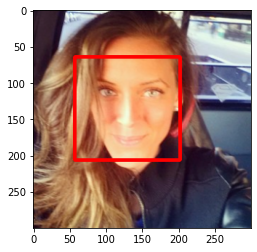

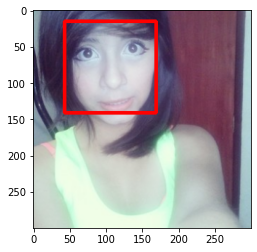

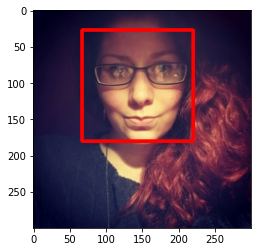

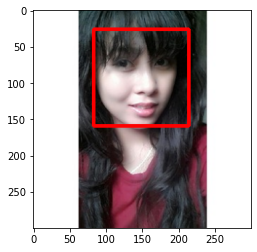

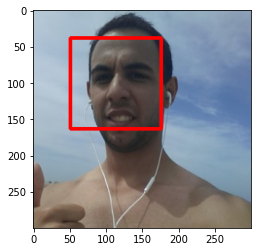

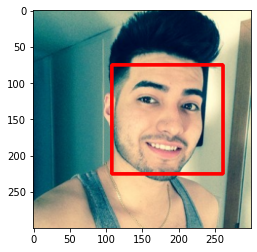

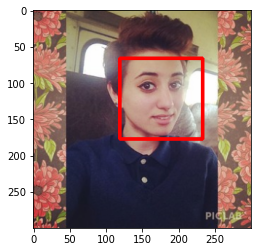

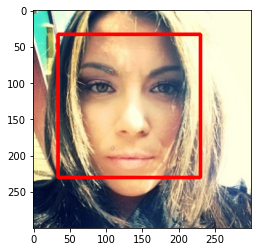

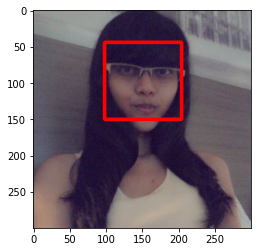

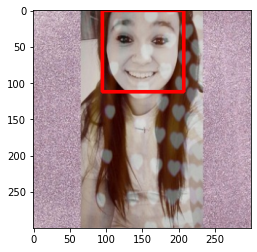

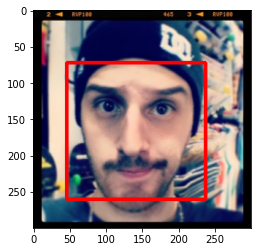

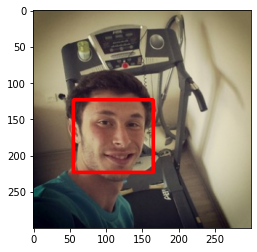

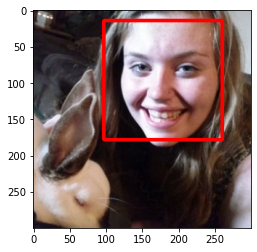

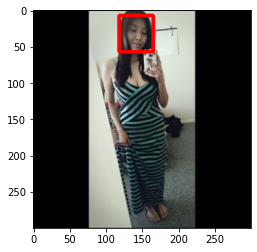

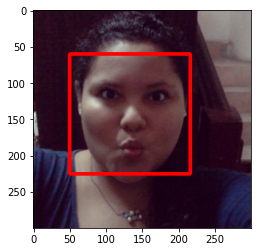

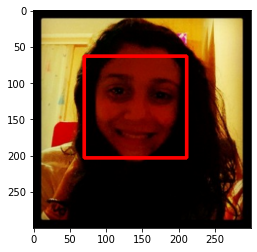

In [ ]:
for inputs, labels in test_dataset:
    bbox_preds = bbox_regressor(inputs, training=False).numpy()
    bbox_preds = (bbox_preds * (dataset_generator.target_shape * 2)).astype(int)
    imgs = (127 * (inputs + 1)).numpy().astype(np.uint8)
    for idx, img in enumerate(imgs):
        x1, y1, x2, y2 = bbox_preds[idx]
        img = cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 4)
        plt.imshow(img)
        plt.show()
    break